# LSTM Text Generation

Word-level sequence model trained on English sentences from the [Tatoeba](https://tatoeba.org/) bilingual corpus. Demonstrates a two-layer LSTM with one-hot encoding, early stopping, perplexity tracking, and temperature-controlled generation.

In [1]:
from io import open
import unicodedata
import random
import re

import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Subset
from torch.utils.data import TensorDataset, DataLoader
import time, copy
import matplotlib.pyplot as plt
import sklearn.metrics as metrics

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Dataset

English sentences from the Tatoeba English-Spanish corpus. Only the English side is used; sentences are normalized to ASCII and lowercased.

In [2]:
# Here we download and unzip the text file that contains all of our translated phrases
!rm -f spa-eng.zip _about.txt spa.txt
!wget https://www.manythings.org/anki/spa-eng.zip
!unzip spa-eng.zip
!ls

--2026-05-19 17:28:55--  https://www.manythings.org/anki/spa-eng.zip
Resolving www.manythings.org (www.manythings.org)... 173.254.30.110
Connecting to www.manythings.org (www.manythings.org)|173.254.30.110|:443... 

connected.


HTTP request sent, awaiting response... 

200 OK
Length: 5502374 (5.2M) [application/zip]
Saving to: ‘spa-eng.zip’

spa-eng.zip           0%[                    ]       0  --.-KB/s               

spa-eng.zip           2%[                    ] 109.20K   517KB/s               

spa-eng.zip          18%[==>                 ] 968.57K  2.24MB/s               

spa-eng.zip         100%[===================>]   5.25M  8.74MB/s    in 0.6s    

2026-05-19 17:28:56 (8.74 MB/s) - ‘spa-eng.zip’ saved [5502374/5502374]



Archive:  spa-eng.zip
  inflating: _about.txt              
  inflating: spa.txt                 

LSTM_Based_Text_Generation_for_Sequence_Learning.ipynb	_about.txt   spa.txt
README.md						spa-eng.zip


## Preprocessing

Convert Unicode → ASCII, lowercase, strip punctuation while preserving word boundaries.

In [3]:
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

# Lowercase, trim, and remove non-letter characters
def normalizeString(s):
    s = unicodeToAscii(s.lower().strip())
    s = re.sub(r"([.!?])", r"", s)
    s = re.sub(r"[^a-zA-Z.!'?]+", r" ", s)
    return s

def parse_data(filename):
    lines = open(filename, encoding='utf-8').read().strip().split('\n')
    pairs = [[normalizeString(s) for s in l.split('\t')] for l in lines]
    pairs = [[pair[0], pair[1]] for pair in pairs]
    return pairs

## Data Split

1,000 sentences each for train / val / test, randomly sampled from 141k total.

In [4]:
pairs = parse_data("spa.txt")
english_sentences = [pair[0] for pair in pairs]
random.shuffle(english_sentences)
print("Number of English sentences:", len(english_sentences))

train_sentences = english_sentences[:1000]
val_sentences = english_sentences[1000:2000]
test_sentences = english_sentences[2000:3000]

Number of English sentences: 144215


## EDA

Quick look at the distribution of sentence lengths across all 3,000 samples.

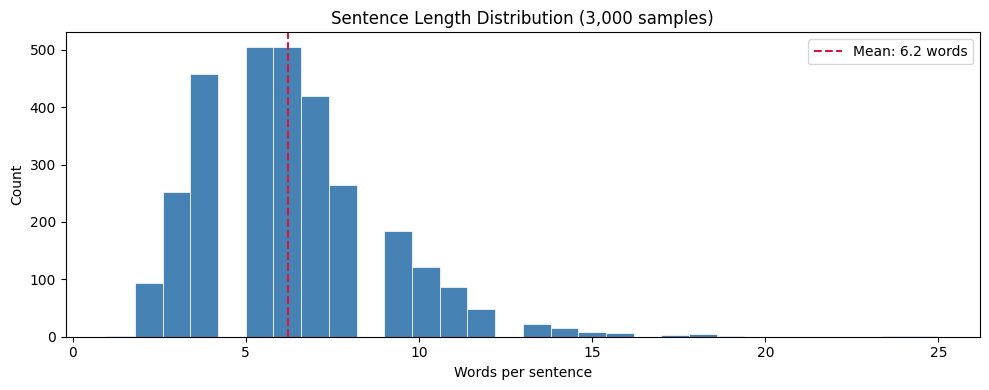

Min: 1  Max: 25  Mean: 6.2  Median: 6


In [5]:
import collections

all_sentences = train_sentences + val_sentences + test_sentences
lengths = [len(s.split()) for s in all_sentences]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(lengths, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(sum(lengths)/len(lengths), color='crimson', linestyle='--',
           label=f'Mean: {sum(lengths)/len(lengths):.1f} words')
ax.set_xlabel('Words per sentence')
ax.set_ylabel('Count')
ax.set_title('Sentence Length Distribution (3,000 samples)')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Min: {min(lengths)}  Max: {max(lengths)}  "
      f"Mean: {sum(lengths)/len(lengths):.1f}  Median: {sorted(lengths)[len(lengths)//2]}")

## Vocabulary

Build a word → index mapping from all three splits so no OOV words crash inference.

In [6]:
# Using this function we will create a dictionary to use for our one hot encoding vectors
def add_words_to_dict(word_dictionary, word_list, sentences):
    for sentence in sentences:
        for word in sentence.split(" "):
            if word in word_dictionary:
                continue
            else:
                word_list.append(word)
                word_dictionary[word] = len(word_list)-1

english_dictionary = {}
english_list = []
add_words_to_dict(english_dictionary, english_list, train_sentences)
add_words_to_dict(english_dictionary, english_list, val_sentences)
add_words_to_dict(english_dictionary, english_list, test_sentences)

### Vocabulary Frequency

Top-25 words in the combined corpus. Grammatical function words dominate, which is typical for English.

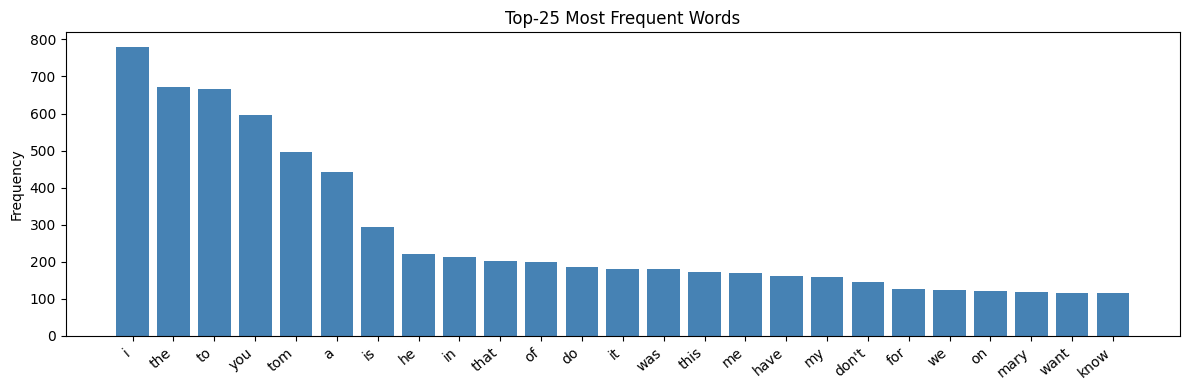

Unique tokens in corpus: 2,653  |  Model vocabulary: 2,654


In [7]:
word_counts = collections.Counter(w for s in all_sentences for w in s.split())
top_words, top_counts = zip(*word_counts.most_common(25))

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(top_words)), top_counts, color='steelblue')
ax.set_xticks(range(len(top_words)))
ax.set_xticklabels(top_words, rotation=40, ha='right')
ax.set_ylabel('Frequency')
ax.set_title('Top-25 Most Frequent Words')
plt.tight_layout()
plt.show()
print(f"Unique tokens in corpus: {len(word_counts):,}  |  Model vocabulary: {len(english_dictionary):,}")

## Tensor Encoding

One-hot encode each word into a `(seq_len, 1, vocab_size+1)` tensor. The extra index (`vocab_size`) serves as the EOS token.

In [8]:
def create_input_tensor(sentence, word_dictionary):
    words = sentence.split(" ")
    tensor = torch.zeros(len(words), 1, len(word_dictionary) + 1)
    for idx, word in enumerate(words):
        if word in word_dictionary:
            tensor[idx][0][word_dictionary[word]] = 1
    return tensor

def create_target_tensor(sentence, word_dictionary):
    words = sentence.split(" ")
    tensor = torch.zeros(len(words), 1, len(word_dictionary) + 1)
    for idx in range(1, len(words)):
        word = words[idx]
        if word in word_dictionary:
            tensor[idx - 1][0][word_dictionary[word]] = 1
    tensor[len(words) - 1][0][len(word_dictionary)] = 1 # EOS
    return tensor

train_tensors = [(create_input_tensor(sentence, english_dictionary), create_target_tensor(sentence, english_dictionary)) for sentence in train_sentences]
val_tensors = [(create_input_tensor(sentence, english_dictionary), create_target_tensor(sentence, english_dictionary)) for sentence in val_sentences]
test_tensors = [(create_input_tensor(sentence, english_dictionary), create_target_tensor(sentence, english_dictionary)) for sentence in test_sentences]

## Dataloaders

In [9]:
dataloaders = {'train': train_tensors, 'val': val_tensors, 'test': test_tensors}
dataset_sizes = {phase: len(dataloaders[phase]) for phase in dataloaders}
print(f'dataset_sizes = {dataset_sizes}')

dataset_sizes = {'train': 1000, 'val': 1000, 'test': 1000}


## Model Architecture

Two-layer LSTM with 30% dropout between layers and before the output projection. Using one-hot input (rather than a learned embedding) keeps the architecture explicit and makes the vocabulary bottleneck visible in the parameter count.

In [10]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout=0.3):
        super(LSTM, self).__init__()
        self.hidden_size = hidden_size
        # Add dropout to the LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=2, dropout=dropout)  # Dropout between layers
        self.fc = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout)  # Dropout before the fully connected layer

    def forward(self, input, hidden):
        output, hidden = self.lstm(input, hidden)
        output = self.dropout(output[-1])  # Apply dropout before the fully connected layer
        output = self.fc(output)
        return output, hidden

    def initHidden(self, batch_size):
        return (torch.zeros(2, batch_size, self.hidden_size).to(device),
                torch.zeros(2, batch_size, self.hidden_size).to(device))

## Initialize Model

In [11]:
input_size = len(english_dictionary) + 1
hidden_size = 128
output_size = len(english_dictionary) + 1

lstm_model = LSTM(input_size=input_size, hidden_size=hidden_size, output_size=output_size).to(device)

total_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"Vocabulary size : {len(english_dictionary):,}")
print(f"Trainable params: {total_params:,}")

Vocabulary size : 2,654
Trainable params: 1,900,511


## Hyperparameters

In [12]:
learning_rate = 0.001
num_epochs = 10
weight_decay = 0.01  # L2 regularization parameter

## Training

Early stopping (patience=3) on validation loss. Each epoch reports loss and perplexity (exp of cross-entropy loss) for all three splits.

In [13]:
def train_lstm(model, dataloaders, dataset_sizes, criterion, optimizer, scheduler, num_epochs=25, patience=3):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = np.inf
    epochs_no_improve = 0

    training_curves = {f'{phase}_{m}': [] for phase in ['train', 'val', 'test'] for m in ['loss', 'perplexity']}

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val', 'test']:
            model.train() if phase == 'train' else model.eval()
            running_loss = 0.0

            for input_sequence, target_sequence in dataloaders[phase]:
                hidden = model.initHidden(batch_size=input_sequence.size(1))

                current_input_sequence = input_sequence.unsqueeze(1).to(device)
                current_target_sequence = target_sequence.to(device)

                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    loss = 0
                    for i in range(current_input_sequence.size(0)):
                        current_hidden = (hidden[0].to(device), hidden[1].to(device))
                        output, hidden = model(current_input_sequence[i], current_hidden)
                        l = criterion(output, current_target_sequence[i])
                        loss += l

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() / current_input_sequence.size(0)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_ppl = np.exp(epoch_loss)
            training_curves[f'{phase}_loss'].append(epoch_loss)
            training_curves[f'{phase}_perplexity'].append(epoch_ppl)

            print(f'{phase:5} Loss: {epoch_loss:.4f}  Perplexity: {epoch_ppl:.1f}')

            if phase == 'val':
                if epoch_loss < best_loss:
                    best_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f'Early stopping triggered after {epoch+1} epochs.')
            break

    time_elapsed = time.time() - since
    print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Loss: {best_loss:.4f}  Perplexity: {np.exp(best_loss):.1f}')

    model.load_state_dict(best_model_wts)
    return model, training_curves

## Inference

`temperature=0` uses greedy argmax. Higher temperatures diversify output by sampling from the softmax distribution; lower temperatures (but > 0) sharpen it.

In [14]:
def predict(model, word_dictionary, word_list, input_sentence, max_length=20, temperature=0.0):
    output_sentence = input_sentence + " "
    tensor = create_input_tensor(input_sentence, word_dictionary).to(device)
    hidden = model.initHidden(batch_size=1)

    model.eval()
    with torch.no_grad():
        for i in range(tensor.size(0)):
            output, hidden = model(tensor[i:i+1], hidden)  # keep 3D: (1, batch, vocab)

        for _ in range(max_length):
            if temperature == 0.0:
                _, topi = output.topk(1)
                topi = topi[0][0].item()
            else:
                probs = torch.softmax(output.squeeze() / temperature, dim=-1)
                topi = torch.multinomial(probs, 1).item()

            if topi == len(word_dictionary):
                break

            word = word_list[topi]
            output_sentence += word + " "

            next_tensor = create_input_tensor(word, word_dictionary).to(device)
            output, hidden = model(next_tensor[0:1], hidden)

    return output_sentence.strip()

## Run Training

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

# Train the model and collect training curves for visualization
lstm_model, training_curves = train_lstm(lstm_model, dataloaders, dataset_sizes,
                                         criterion, optimizer, scheduler, num_epochs=num_epochs)



Epoch 1/10
----------


train Loss: 6.0253  Perplexity: 413.8


val   Loss: 5.7785  Perplexity: 323.3


test  Loss: 5.7531  Perplexity: 315.2

Epoch 2/10
----------


train Loss: 5.7366  Perplexity: 310.0


...

val   Loss: 5.7062  Perplexity: 300.7


test  Loss: 5.6954  Perplexity: 297.5

Epoch 10/10
----------


train Loss: 5.3555  Perplexity: 211.8


val   Loss: 5.6984  Perplexity: 298.4


test  Loss: 5.6865  Perplexity: 294.9

Training complete in 2m 28s
Best val Loss: 5.6984  Perplexity: 298.4


## Training Curves

In [16]:
# Plotting function to visualize training curves
def plot_training_curves(training_curves, phases=['train', 'val', 'test'], metrics=['loss']):
    epochs = list(range(len(training_curves['train_loss'])))
    for metric in metrics:
        plt.figure()
        plt.title(f'Training curves - {metric}')
        for phase in phases:
            key = phase + '_' + metric
            if key in training_curves:
                plt.plot(epochs, training_curves[key], label=phase)
        plt.xlabel('Epoch')
        plt.ylabel(metric.capitalize())
        plt.legend()
        plt.show()

### Loss and Perplexity

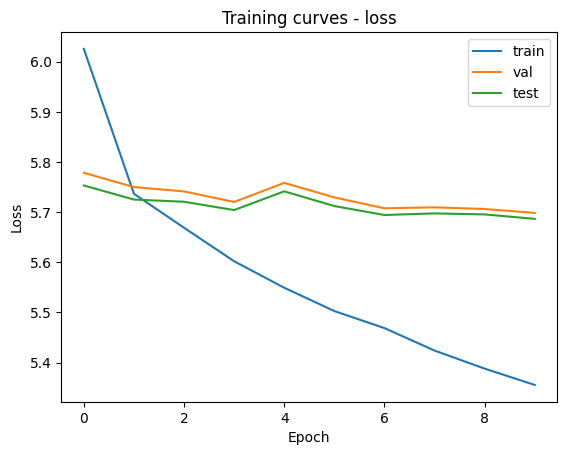

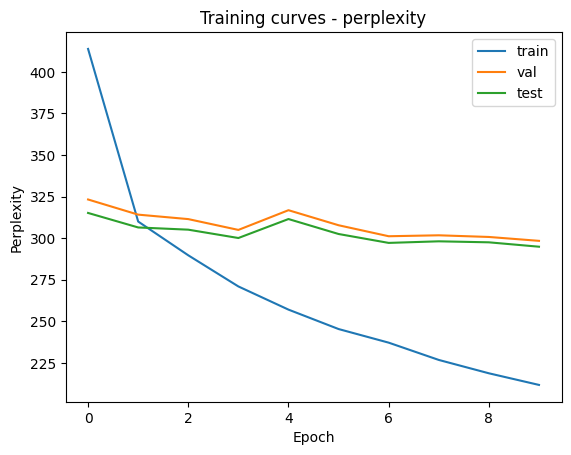

In [17]:
plot_training_curves(training_curves, phases=['train', 'val', 'test'], metrics=['loss', 'perplexity'])

## Generation Examples

Greedy decoding vs. temperature sampling from the same prompt. Temperature = 0 is deterministic; higher values introduce diversity.

In [18]:
prompts = ["i am", "she is", "we need to", "the cat"]
temperatures = [0.0, 0.5, 1.0]

lstm_model.eval()
for prompt in prompts:
    print(f"Prompt: '{prompt}'")
    for t in temperatures:
        label = "greedy" if t == 0.0 else f"temp={t}"
        result = predict(lstm_model, english_dictionary, english_list, prompt, max_length=15, temperature=t)
        print(f"  {label:10s}: {result}")
    print()

Prompt: 'i am'
  greedy    : i am to to
  temp=0.5  : i am was the
  temp=1.0  : i am most keys his but

Prompt: 'she is'
  greedy    : she is to to
  temp=0.5  : she is the lot
  temp=1.0  : she is it him her lucky you of

Prompt: 'we need to'
  greedy    : we need to to
  temp=0.5  : we need to the
  temp=1.0  : we need to always the crime

Prompt: 'the cat'
  greedy    : the cat you to
  temp=0.5  : the cat to to
  temp=1.0  : the cat mask know pain chocolate



## Save Model

Persist the trained weights and vocabulary so the Flask API can load them without retraining.

In [ ]:
import os, json

SAVE_DIR = 'api/saved'
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(lstm_model.state_dict(), os.path.join(SAVE_DIR, 'model.pt'))
with open(os.path.join(SAVE_DIR, 'vocab.json'), 'w') as f:
    json.dump({'word_dict': english_dictionary, 'word_list': english_list,
               'vocab_size': len(english_dictionary) + 1}, f)

print(f'Saved to {SAVE_DIR}/')
print(f'  model.pt  vocab_size={len(english_dictionary)+1}')

## Next-Word Prediction Analysis

For a given prompt, visualize the model's softmax distribution over the top-10 predicted next words. This is the clearest window into what the LSTM learned about English word order and co-occurrence.

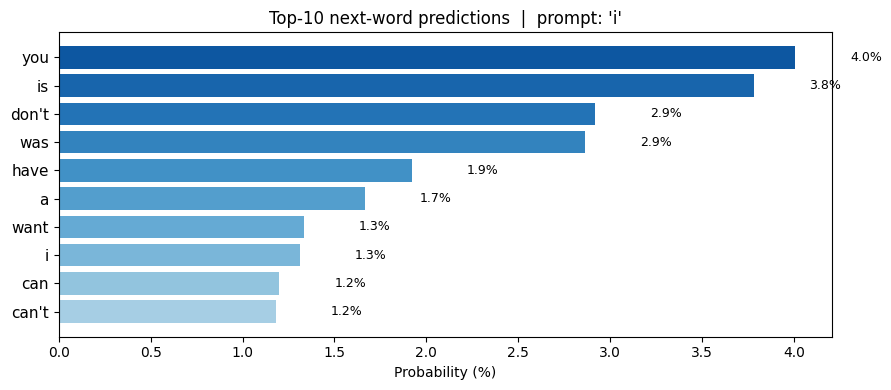

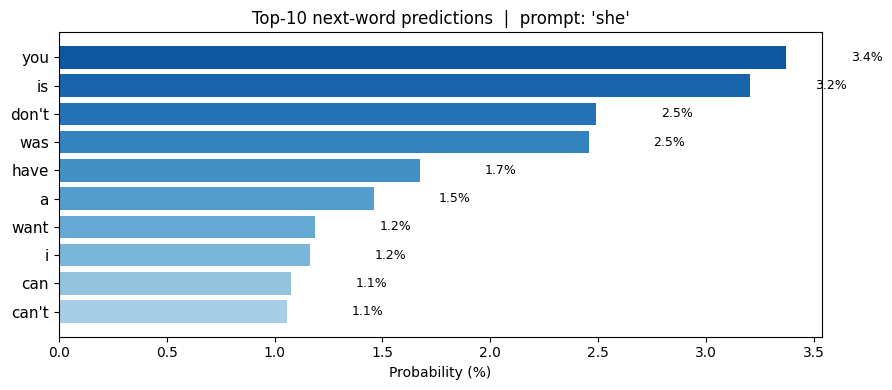

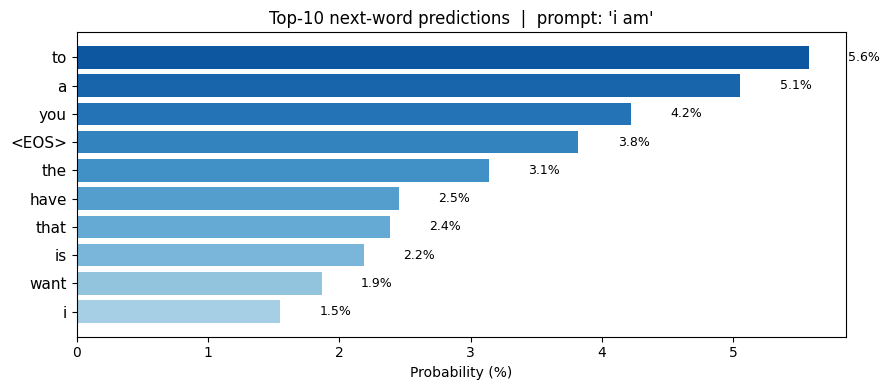

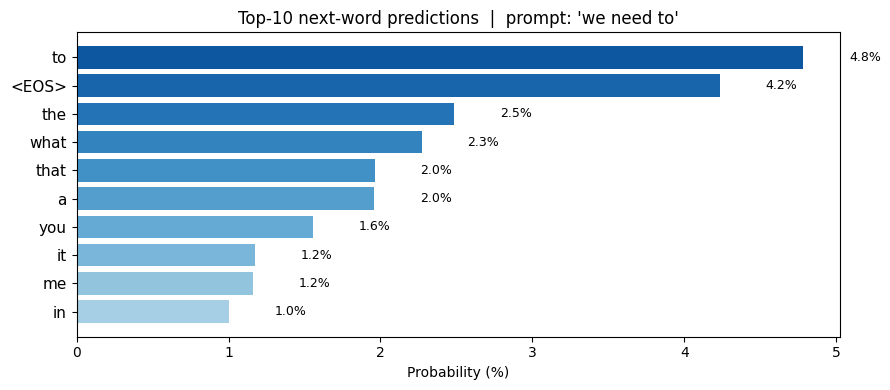

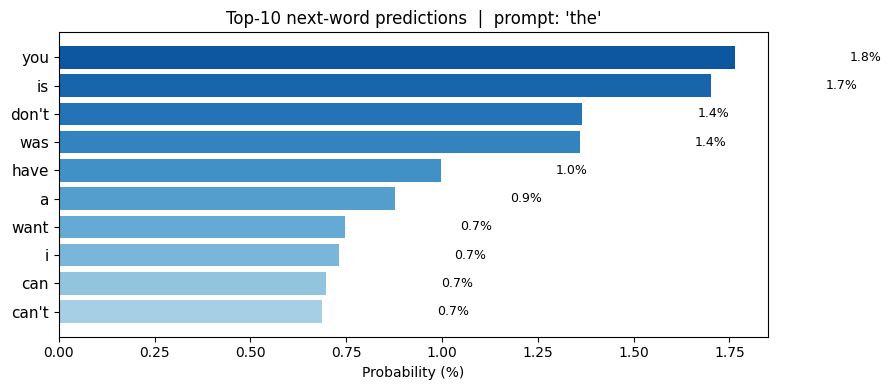

In [19]:
import torch.nn.functional as F

def plot_top_k_predictions(model, word_dictionary, word_list, prompt, k=10):
    model.eval()
    with torch.no_grad():
        tensor = create_input_tensor(prompt, word_dictionary).to(device)
        hidden = model.initHidden(batch_size=1)
        for i in range(tensor.size(0)):
            output, hidden = model(tensor[i:i+1], hidden)
        probs = F.softmax(output.squeeze(), dim=-1)
        topk_probs, topk_idx = probs.topk(k)

    words_k = [word_list[i] if i < len(word_list) else '<EOS>'
               for i in topk_idx.cpu().numpy()]
    pct = topk_probs.cpu().numpy() * 100

    fig, ax = plt.subplots(figsize=(9, 4))
    colors = plt.cm.Blues(np.linspace(0.35, 0.85, k))[::-1]
    bars = ax.barh(range(k - 1, -1, -1), pct, color=colors)
    ax.set_yticks(range(k - 1, -1, -1))
    ax.set_yticklabels(words_k, fontsize=11)
    ax.set_xlabel('Probability (%)')
    ax.set_title(f"Top-{k} next-word predictions  |  prompt: '{prompt}'")
    for bar, p in zip(bars, pct):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                f'{p:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

for prompt in ["i", "she", "i am", "we need to", "the"]:
    plot_top_k_predictions(lstm_model, english_dictionary, english_list, prompt)

## Hidden State Dynamics

For each word in a sentence, plot the L2 norm of the LSTM's top-layer hidden state. Spikes indicate moments where the model updates its representation strongly — often at semantically significant or structurally unexpected words.

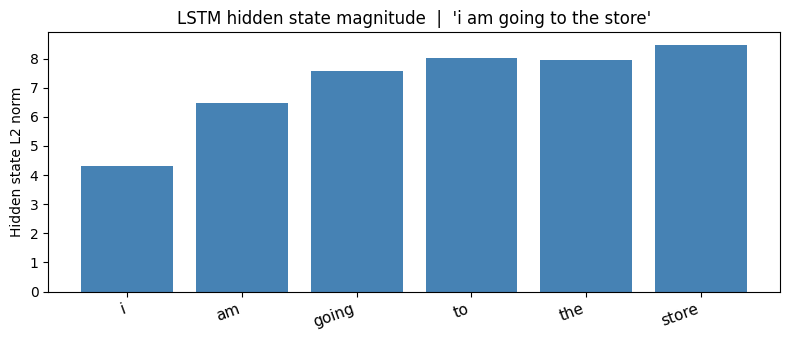

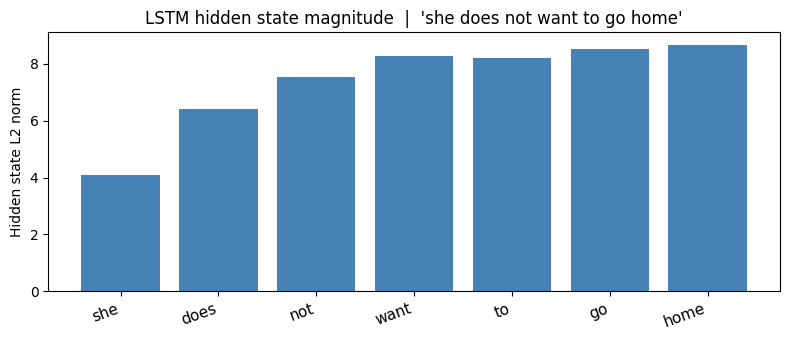

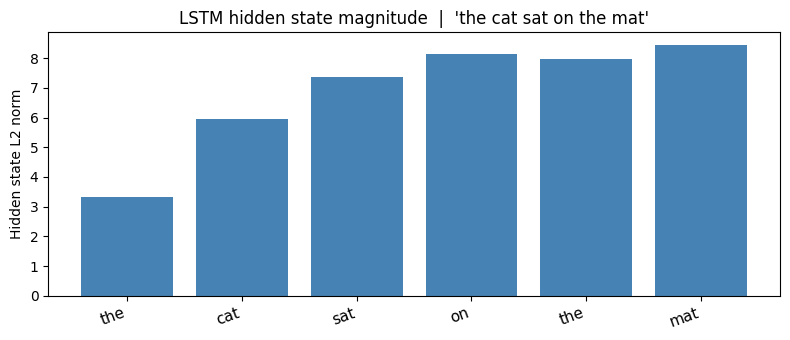

In [20]:
def plot_hidden_dynamics(model, word_dictionary, sentence):
    model.eval()
    words = sentence.split()
    norms = []
    with torch.no_grad():
        tensor = create_input_tensor(sentence, word_dictionary).to(device)
        hidden = model.initHidden(batch_size=1)
        for i in range(tensor.size(0)):
            output, hidden = model(tensor[i:i+1], hidden)
            norms.append(hidden[0][-1].squeeze().norm().item())  # last-layer hidden norm

    fig, ax = plt.subplots(figsize=(max(8, len(words)), 3.5))
    ax.bar(range(len(words)), norms, color='steelblue')
    ax.set_xticks(range(len(words)))
    ax.set_xticklabels(words, rotation=20, ha='right', fontsize=11)
    ax.set_ylabel('Hidden state L2 norm')
    ax.set_title(f"LSTM hidden state magnitude  |  '{sentence}'")
    plt.tight_layout()
    plt.show()

for sentence in [
    "i am going to the store",
    "she does not want to go home",
    "the cat sat on the mat",
]:
    plot_hidden_dynamics(lstm_model, english_dictionary, sentence)